Saving dataset.xlsx to dataset (11).xlsx
Dataset shape: (1008, 11)

Columns:
Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'EnergyConsumption'],
      dtype='object')

Data types:
Timestamp            datetime64[ns]
Temperature                  object
Humidity                     object
SquareFootage                object
Occupancy                    object
HVACUsage                    object
LightingUsage                object
RenewableEnergy              object
DayOfWeek                    object
Holiday                      object
EnergyConsumption            object
dtype: object


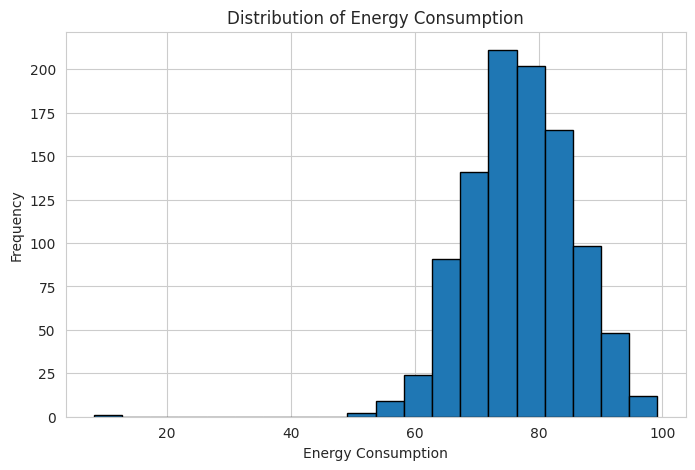

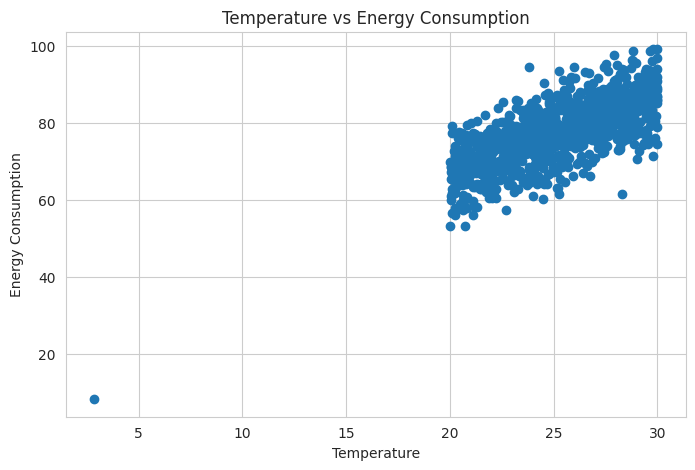

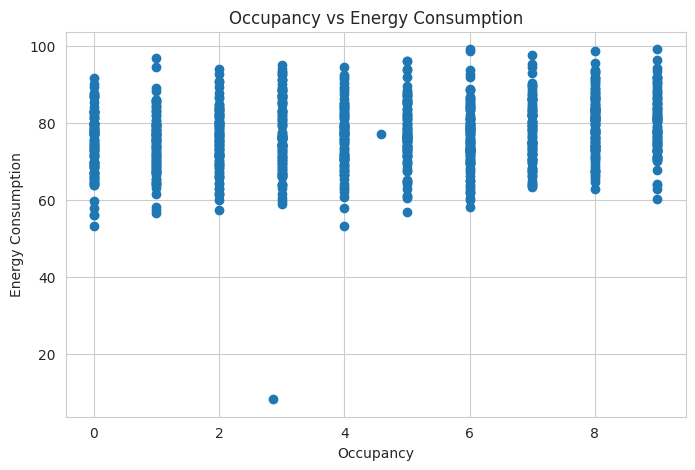

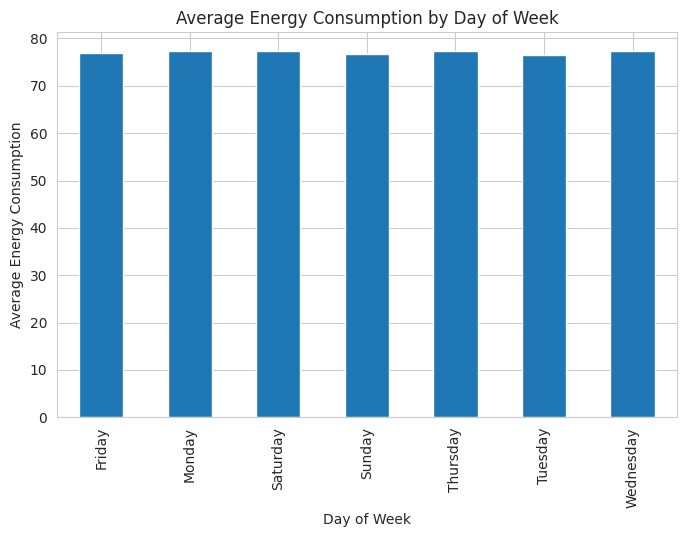

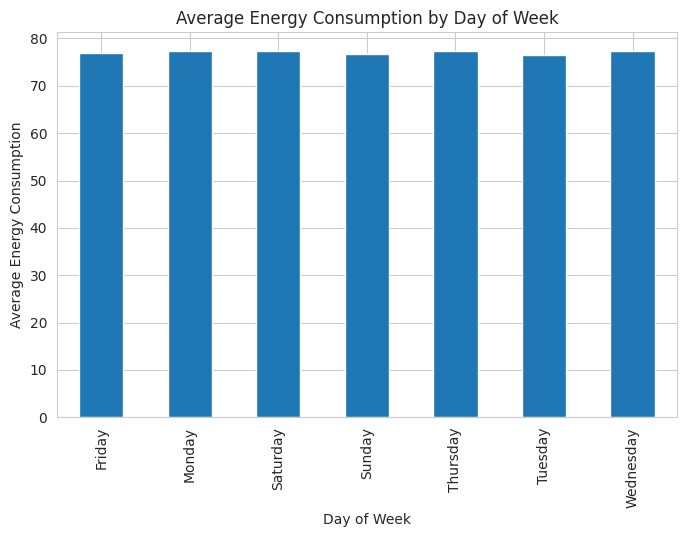

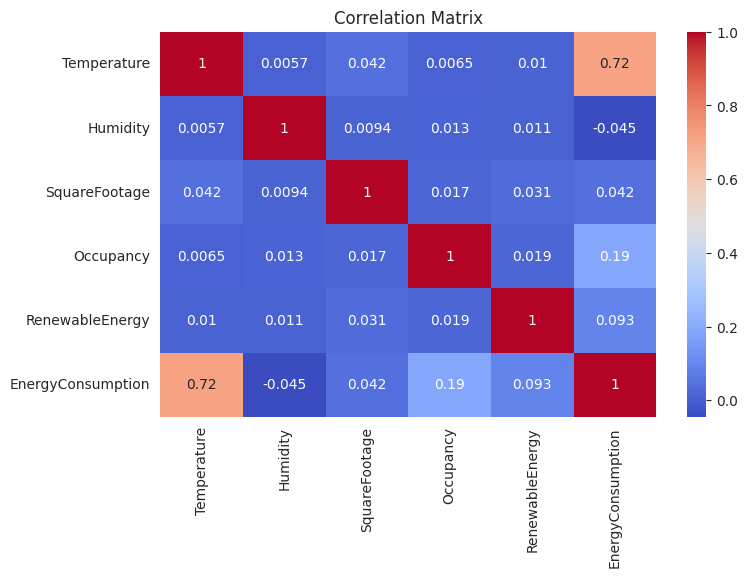

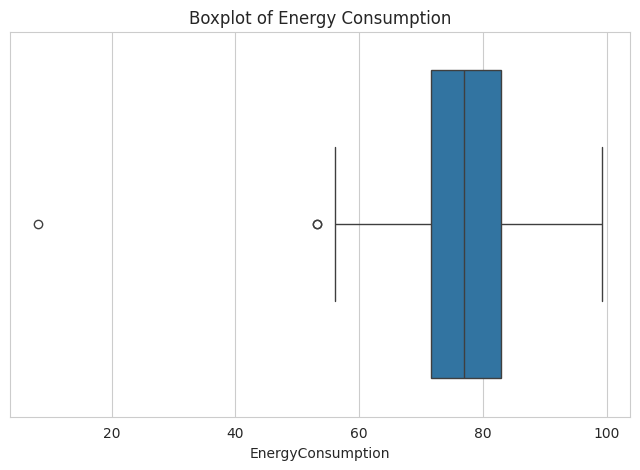

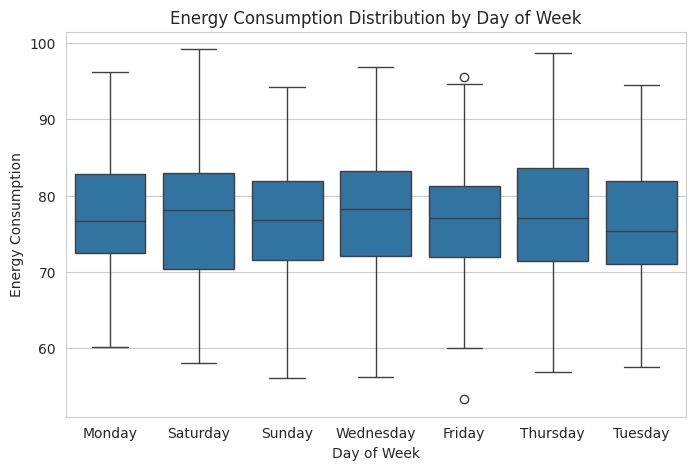

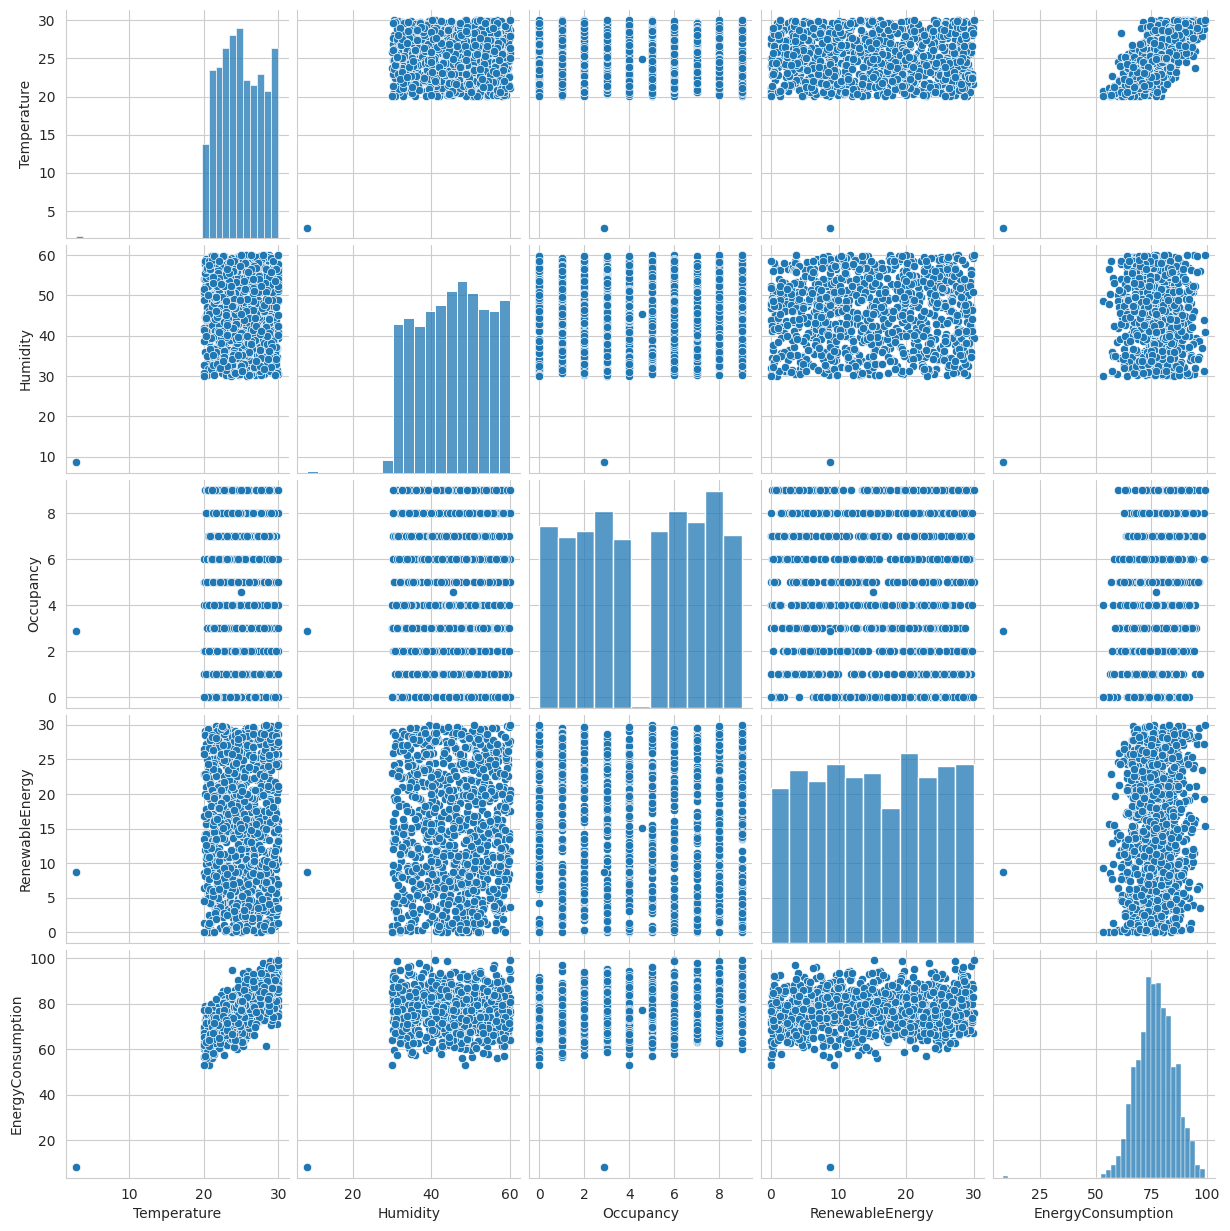

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("dataset.xlsx")
df.head()
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

# Convert 'EnergyConsumption' to numeric, coercing errors, then drop NaNs
df["EnergyConsumption"] = pd.to_numeric(df["EnergyConsumption"], errors='coerce')
df.dropna(subset=["EnergyConsumption"], inplace=True)

df.isnull().sum()
df.describe()
plt.hist(df["EnergyConsumption"], bins=20, edgecolor="black")
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
plt.show()
plt.scatter(df["Temperature"], df["EnergyConsumption"])
plt.title("Temperature vs Energy Consumption")
plt.xlabel("Temperature")
plt.ylabel("Energy Consumption")
plt.show()
plt.scatter(df["Occupancy"], df["EnergyConsumption"])
plt.title("Occupancy vs Energy Consumption")
plt.xlabel("Occupancy")
plt.ylabel("Energy Consumption")
plt.show()
avg_energy = df.groupby("DayOfWeek")["EnergyConsumption"].mean()

avg_energy.plot(kind="bar")
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption")
plt.show()
avg_energy = df.groupby("DayOfWeek")["EnergyConsumption"].mean()

avg_energy.plot(kind="bar")
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption")
plt.show()
numerical_cols = ["Temperature","Humidity","SquareFootage","Occupancy","RenewableEnergy","EnergyConsumption"]

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
sns.boxplot(x=df["EnergyConsumption"])
plt.title("Boxplot of Energy Consumption")
plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(x="DayOfWeek", y="EnergyConsumption", data=df)

plt.title("Energy Consumption Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Energy Consumption")

plt.show()
sns.pairplot(df[["Temperature","Humidity","Occupancy","RenewableEnergy","EnergyConsumption"]])
plt.show()